In [1]:
"""
rolling_window.py -- sliding-window stability probe over the full span.

Question: does a freshly-trained recent model (52wk trailing) with recent
calibration track week to week, and where do skill / ranking / calibration
break? Tests the micro-regime postulate directly.

WINDOW (all widths in calendar weeks; sessions = distinct trading dates in range)
  train : [cursor, cursor+52wk)          -- always 52 weeks; empty => exception
  iso   : starts cursor+52wk, base 2 wk  -- extend 1 wk while <= ISO_MIN_SESS sessions
  test  : 1 wk, starts at actual iso_end -- flat, no stretch
  step  : cursor advances 1 wk each iteration (independent of iso stretch;
          consecutive steps overlap in iso/test -- expected)

CORRECTNESS
  - X / y / meta are built ONCE over the whole span, same order (one _selected
    walk). Rows are selected ONLY by boolean date-masks on meta["date"], never
    by position -- positional slicing on concatenated sessions is where windows
    misalign; date-masks self-identify per row and cannot.
  - Step 1 asserts train/iso/test row-index sets are pairwise DISJOINT and their
    date ranges do not overlap (within-step). Fails loudly on step 1 rather than
    silently corrupting the sweep. (Across steps they DO overlap -- by design.)
  - A step is emitted only if train non-empty (else exception), iso reaches its
    session floor before end-of-data, and test has >= 1 session. Otherwise the
    tail steps are dropped and counted.

METRICS (each on that step's OWN test rows)
  skill  = 1 - ll_cal / ll_const,  ll_const from the TEST week's own base rate
  auc    = roc_auc on raw p        (ranking; calibration-independent)
  ll_gap = ll(y,p) - ll(y,p_cal)   (calibration-drift sensor; <0 => iso stale
                                     for this week even though ranking may hold)
  keyed by test-week START date (forward edge).
"""

import json
import time
import numpy as np
import pandas as pd
import joblib
import lightgbm as lgb
from scipy.signal import lfilter
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import log_loss, roc_auc_score

from common import Featurizer, load_manifest, _expanding_z

# ---------------------------------------------------------------- CONFIG
FRAME = 3
STAGE0_TAG = "mnq-TICK-9-12am"
MANIFEST_PATH = f"stage-0/manifest_{STAGE0_TAG}_{FRAME}s.json"
BARS_PATH = f"stage-0/bars_{STAGE0_TAG}_{FRAME}s.pqt"
EVENTS_PATH = f"stage-0/events_{STAGE0_TAG}_{FRAME}s.pqt"

TRAIN_WEEKS = 52
ISO_BASE_WEEKS = 2
ISO_MIN_SESS = 8              # extend iso by 1wk while sessions <= this
TEST_WEEKS = 1
STEP_WEEKS = 1
TEST_MIN_SESS = 4            # extend test by 1wk while sessions <= this

# from stage-5

LGBM_PARAMS = dict(
    objective="binary", metric="binary_logloss", learning_rate=0.05,
    num_leaves=127, min_data_in_leaf=1000, feature_fraction=0.9,
    bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0,
    num_threads=16, verbosity=-1,
)
NUM_ROUNDS = 8000
EARLY_STOP = 200
TAUS = (2.0, 6.0, 18.0)
VALUE_LAGS = (1, 2)     
ZWARM = 20
TOD_BIN_MIN = 30
BODY_TAG = "raw"
BODY_OPEN_COL = "rawOpen"
BODY_CLOSE_COL = "rawLast"

#

OUT_CSV = f"rolling/{STAGE0_TAG}_{BODY_TAG}_{FRAME}s.csv"
PLOT = True
WK = pd.Timedelta(weeks=1)
# ----------------------------------------------------------------

In [2]:
####################### STAGE 5 COPY PASTE #######################
#from stage_5 import (build_X, build_meta, LGBM_PARAMS, NUM_ROUNDS, EARLY_STOP, ZWARM, TOD_BIN_MIN, TAUS)

def build_X(fz, src, date_from=None, date_to=None):
    Xg, gn = build_grammar_features(fz, date_from, date_to)
    Xv, vn = build_value_features(fz, src, date_from, date_to)
    assert len(Xg) == len(Xv), (len(Xg), len(Xv))
    return np.hstack([Xg, Xv]), gn + vn


def build_meta(fz, date_from=None, date_to=None):
    bi, ts, tg, dt = [], [], [], []
    for S in fz._selected(date_from, date_to):
        t = np.nonzero(~S["warm"])[0]
        bi.append(S["bar_index"][t])
        ts.append(S["timestamp"][t])
        tg.append(S["tgt"][t])
        dt.append(np.full(len(t), str(S["sess"])))
    return pd.DataFrame({"bar_index": np.concatenate(bi),
                         "timestamp": np.concatenate(ts),
                         "is_target": np.concatenate(tg),
                         "date": np.concatenate(dt)})

def build_grammar_features(fz, date_from=None, date_to=None):
    blocks = []
    for S in fz._selected(date_from, date_to):
        t = np.nonzero(~S["warm"])[0]
        n = S["n"]
        cols = []
        for c in fz.classes:
            P = S["P"][c]
            ind = np.diff(P).astype(np.float64)
            occ = np.where(ind > 0, np.arange(n), -1)
            last = np.maximum.accumulate(occ)
            lastm1 = np.concatenate(([-1], last[:-1]))
            bsince = np.where(lastm1 >= 0, np.arange(n) - lastm1, np.arange(n) + 1)
            cols.append(bsince[t])
            x = np.concatenate(([0.0], ind[:-1]))
            for tau in TAUS:
                a = np.exp(-1.0 / tau)
                s = lfilter([a], [1.0, -a], x)
                cols.append(s[t])
        lt = np.where(t > 0, S["lt_incl"][np.maximum(t - 1, 0)], -1)
        age = np.where(lt >= 0, t - lt, t + 1)
        cols.append(age)
        cols.append(S["tod"][t].astype(np.float64))
        blocks.append(np.stack(cols, 1).astype(np.float32))
    return np.concatenate(blocks), fz.grammar_names

def value_base_names(manifest):
    """Value channels derived from the manifest stream set (source columns)."""
    cols = manifest["_stream_cols"]
    names = ([f"z_{c}_signed" for c in cols]
             + [f"z_{c}_mag" for c in cols]
             + ["z_leg_amp", f"z_body_{BODY_TAG}_signed", f"z_body_{BODY_TAG}_mag"])
    return cols, names

def build_value_features(fz, src, date_from=None, date_to=None):
    cols, base = value_base_names(fz.manifest)
    names = base + [f"{nm}_lag{L}" for L in VALUE_LAGS for nm in base]
    sv = src.set_index("timestamp")
    blocks = []
    for S in fz._selected(date_from, date_to):
        ts = pd.DatetimeIndex(S["timestamp"])
        r = sv.reindex(ts)
        leg_dir = S["leg_dir"]
        feats = []
        for c in cols:                                             # signed per stream col
            feats.append(_expanding_z(r[c].to_numpy(np.float64) * leg_dir, ZWARM))
        for c in cols:                                             # magnitude per stream col
            feats.append(_expanding_z(np.abs(r[c].to_numpy(np.float64)), ZWARM))
        feats.append(_expanding_z(np.abs(r["JMA"].to_numpy(np.float64) - S["leg_start_jma"]), ZWARM))
        bo = r[BODY_OPEN_COL].to_numpy(np.float64)
        bc = r[BODY_CLOSE_COL].to_numpy(np.float64)
        feats.append(_expanding_z((bc - bo) * leg_dir, ZWARM))     # confirming-positive
        feats.append(_expanding_z(np.abs(bc - bo), ZWARM))

        M = np.stack(feats, 1)
        M = np.concatenate([np.zeros((1, M.shape[1])), M[:-1]], 0)          # t-1 shift
        lagged = [M]
        for L in VALUE_LAGS:
            lagged.append(np.concatenate([np.zeros((L, M.shape[1])), M[:-L]], 0))
        M = np.concatenate(lagged, 1)
        t = np.nonzero(~S["warm"])[0]
        Mt = M[t]
        Mt[(t < ZWARM + max(VALUE_LAGS))] = 0.0
        blocks.append(Mt.astype(np.float32))
    return np.concatenate(blocks), names


In [3]:
def load_all():
    manifest = load_manifest(MANIFEST_PATH, TOD_BIN_MIN)
    bars = pd.read_parquet(BARS_PATH)
    events = pd.read_parquet(EVENTS_PATH)
    lo = pd.Timestamp(manifest["session_start"]).time()
    hi = pd.Timestamp(manifest["session_end"]).time()

    src = pd.read_parquet(manifest["source_file"])
    src = src[(src["timestamp"].dt.time >= lo) & (src["timestamp"].dt.time < hi)]
    raw1 = pd.read_parquet(manifest["raw_file"])
    raw1 = raw1[(raw1["timestamp"].dt.time >= lo) & (raw1["timestamp"].dt.time < hi)]
    raw1 = raw1.rename(columns={"Open": "rawOpen", "High": "rawHigh",
                                "Low": "rawLow", "Last": "rawLast"})
    src = src.merge(raw1[["timestamp", "rawOpen", "rawHigh", "rawLow", "rawLast"]],
                    on="timestamp", how="left")
    assert src[["rawOpen", "rawLast"]].notna().all().all()

    fz = Featurizer(bars, events, manifest, TOD_BIN_MIN, TAUS)
    X, names = build_X(fz, src)                         # whole span, ONCE
    meta = build_meta(fz)
    meta = meta.reset_index(drop=True)
    d = pd.to_datetime(meta["date"]).dt.normalize()
    meta["d"] = d
    y = meta["is_target"].to_numpy().astype(np.int8)
    print(f"built X {X.shape}  span {d.min().date()}..{d.max().date()}  "
          f"sessions {d.nunique()}")
    return X, y, meta, names

In [4]:
def sessions_in(dates_sorted, lo, hi):
    """# distinct session-dates in [lo, hi)."""
    a = np.searchsorted(dates_sorted, lo, "left")
    b = np.searchsorted(dates_sorted, hi, "left")
    return b - a


def stretch_end(sess_dates, start, base_weeks, min_sess):
    """Grow a window from base_weeks while sessions <= min_sess.
    Returns end (exclusive) or None if data runs out before the floor."""
    wk = base_weeks
    last = sess_dates[-1]
    while True:
        end = start + wk * WK
        if sessions_in(sess_dates, start, end) > min_sess:
            return end
        if end > last + WK:            # past end of data, floor unreachable
            return None
        wk += 1


def ll(y, p):
    p = np.clip(np.asarray(p, np.float64), 1e-15, 1 - 1e-15)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))


def run():
    X, y, meta, names = load_all()
    d = meta["d"].to_numpy()
    dser = meta["d"]
    sess_dates = np.array(sorted(dser.unique()))       # for session counting

    first = dser.min()
    last = dser.max()
    cursor = first
    rows = []
    checked = False
    dropped_tail = 0
    step_no = 0
    t_sweep = time.time()

    while True:
        tr_lo = cursor
        tr_hi = cursor + TRAIN_WEEKS * WK
        iso_lo = tr_hi
        iso_hi = stretch_end(sess_dates, iso_lo, ISO_BASE_WEEKS, ISO_MIN_SESS)
        if iso_hi is None:
            dropped_tail += 1
            break                                       # ran out of data
        te_lo = iso_hi
        te_hi = stretch_end(sess_dates, te_lo, TEST_WEEKS, TEST_MIN_SESS)
        if te_hi is None:            
            dropped_tail += 1
            break

        tr_m = (d >= tr_lo) & (d < tr_hi)
        iso_m = (d >= iso_lo) & (d < iso_hi)
        te_m = (d >= te_lo) & (d < te_hi)

        step_no += 1
        n_tr_s = sessions_in(sess_dates, tr_lo, tr_hi)
        n_is_s = sessions_in(sess_dates, iso_lo, iso_hi)
        n_te_s = sessions_in(sess_dates, te_lo, te_hi)
        print(f"[{step_no:3d}] train [{tr_lo.date()} .. {tr_hi.date()}) {n_tr_s:3d}sess"
              f"  iso [{iso_lo.date()} .. {iso_hi.date()}) {n_is_s}sess"
              f"  test [{te_lo.date()} .. {te_hi.date()}) {n_te_s}sess", flush=True)
        t_step = time.time()

        if tr_m.sum() == 0:
            raise RuntimeError(f"train window empty at cursor {cursor.date()} "
                               f"[{tr_lo.date()}, {tr_hi.date()})")
        n_te = int(te_m.sum())
        if n_te == 0:                                   # holiday-only test week
            cursor = cursor + STEP_WEEKS * WK
            continue

        if not checked:                                 # step-1 disjointness guard
            itr, iis, ite = np.where(tr_m)[0], np.where(iso_m)[0], np.where(te_m)[0]
            assert not (set(itr) & set(iis)), "train/iso overlap"
            assert not (set(iis) & set(ite)), "iso/test overlap"
            assert not (set(itr) & set(ite)), "train/test overlap"
            assert dser[tr_m].max() < dser[iso_m].min(), "train/iso date overlap"
            assert dser[iso_m].max() < dser[te_m].min(), "iso/test date overlap"
            checked = True

        booster = lgb.train(
            LGBM_PARAMS, lgb.Dataset(X[tr_m], label=y[tr_m], feature_name=names),
            num_boost_round=NUM_ROUNDS,
            valid_sets=[lgb.Dataset(X[iso_m], label=y[iso_m])],
            valid_names=["iso"],
            callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
        p_iso = booster.predict(X[iso_m], num_iteration=booster.best_iteration)
        iso = IsotonicRegression(out_of_bounds="clip").fit(p_iso, y[iso_m])

        yte = y[te_m].astype(np.float64)
        p = booster.predict(X[te_m], num_iteration=booster.best_iteration)
        pc = iso.predict(p)
        a = yte.mean()
        ll_const = ll(yte, np.full_like(yte, a)) if 0 < a < 1 else np.nan
        ll_cal = ll(yte, pc)
        ll_raw = ll(yte, p)
        auc = float(roc_auc_score(yte, p)) if 0 < yte.sum() < len(yte) else np.nan

        rows.append(dict(
            test_start=te_lo, train_start=tr_lo,
            iso_weeks=int(round((iso_hi - iso_lo) / WK)),
            n_train=int(tr_m.sum()), n_iso=int(iso_m.sum()), n_test=n_te,
            n_pos=int(yte.sum()), base_rate=float(a),
            skill=float(1 - ll_cal / ll_const) if ll_const == ll_const else np.nan,
            auc=auc, ll_gap=float(ll_raw - ll_cal),
            best_it=int(booster.best_iteration)))
        
        print(f"{te_lo.date()}  iso{rows[-1]['iso_weeks']}w  n_te={n_te:5d} "
              f"pos={rows[-1]['n_pos']:4d}  skill={rows[-1]['skill']:.3f}  "
              f"auc={auc:.4f}  ll_gap={rows[-1]['ll_gap']:+.4f}  "
              f"[{time.time() - t_step:.1f}s, best_it={booster.best_iteration}]", flush=True)        

        cursor = cursor + STEP_WEEKS * WK

    df = pd.DataFrame(rows)
    df.to_csv(OUT_CSV, index=False)
    
    print(f"\n{len(df)} steps -> {OUT_CSV}   (tail dropped: {dropped_tail})")
    print(f"\n{len(df)} steps in {time.time() - t_sweep:.0f}s -> {OUT_CSV} (tail dropped: {dropped_tail})", flush=True)
    print(df[["skill", "auc", "ll_gap", "base_rate"]].describe().to_string())

    if PLOT and len(df):
        import plotly.graph_objects as go
        from plotly.subplots import make_subplots
        thin = df["n_pos"] < 200                        # flag thin test weeks
        fig = make_subplots(rows=3, cols=1, shared_xaxes=True,
                            vertical_spacing=0.05,
                            subplot_titles=["skill (1wk test)",
                                            "auc (ranking)",
                                            "ll_gap (<0 = calibration stale)"])
        for i, k in enumerate(["skill", "auc", "ll_gap"]):
            fig.add_trace(go.Scatter(x=df["test_start"], y=df[k], mode="lines+markers",
                                     marker=dict(size=3), name=k, showlegend=False),
                          row=i + 1, col=1)
            if thin.any():
                fig.add_trace(go.Scatter(
                    x=df["test_start"][thin], y=df[k][thin], mode="markers",
                    marker=dict(size=6, color="red", symbol="x"),
                    name="thin week", showlegend=(i == 0)), row=i + 1, col=1)
        fig.add_hline(y=0.0, line_dash="dot", row=3, col=1)
        fig.update_layout(height=820, width=1500, template="plotly_white",
                          title=f"rolling {TRAIN_WEEKS}wk train / iso "
                                f"{ISO_BASE_WEEKS}wk+ / {TEST_WEEKS}wk test, "
                                f"step {STEP_WEEKS}wk  [{STAGE0_TAG} {FRAME}s]")
        fig.show()
    return df

built X (4108638, 71)  span 2022-01-03..2026-07-08  sessions 1145
[  1] train [2022-01-03 .. 2023-01-02) 255sess  iso [2023-01-02 .. 2023-01-16) 9sess  test [2023-01-16 .. 2023-01-30) 9sess
2023-01-16  iso2w  n_te=32305 pos=3278  skill=0.619  auc=0.9702  ll_gap=-0.0001  [44.7s, best_it=812]
[  2] train [2022-01-10 .. 2023-01-09) 254sess  iso [2023-01-09 .. 2023-01-23) 9sess  test [2023-01-23 .. 2023-01-30) 5sess
2023-01-23  iso2w  n_te=17948 pos=1800  skill=0.618  auc=0.9697  ll_gap=+0.0001  [44.0s, best_it=851]
[  3] train [2022-01-17 .. 2023-01-16) 254sess  iso [2023-01-16 .. 2023-01-30) 9sess  test [2023-01-30 .. 2023-02-06) 5sess
2023-01-30  iso2w  n_te=17944 pos=1827  skill=0.608  auc=0.9700  ll_gap=-0.0032  [44.4s, best_it=880]
[  4] train [2022-01-24 .. 2023-01-23) 254sess  iso [2023-01-23 .. 2023-02-06) 10sess  test [2023-02-06 .. 2023-02-13) 5sess
2023-02-06  iso2w  n_te=17947 pos=1883  skill=0.608  auc=0.9692  ll_gap=-0.0016  [37.3s, best_it=680]
[  5] train [2022-01-31 .. 20

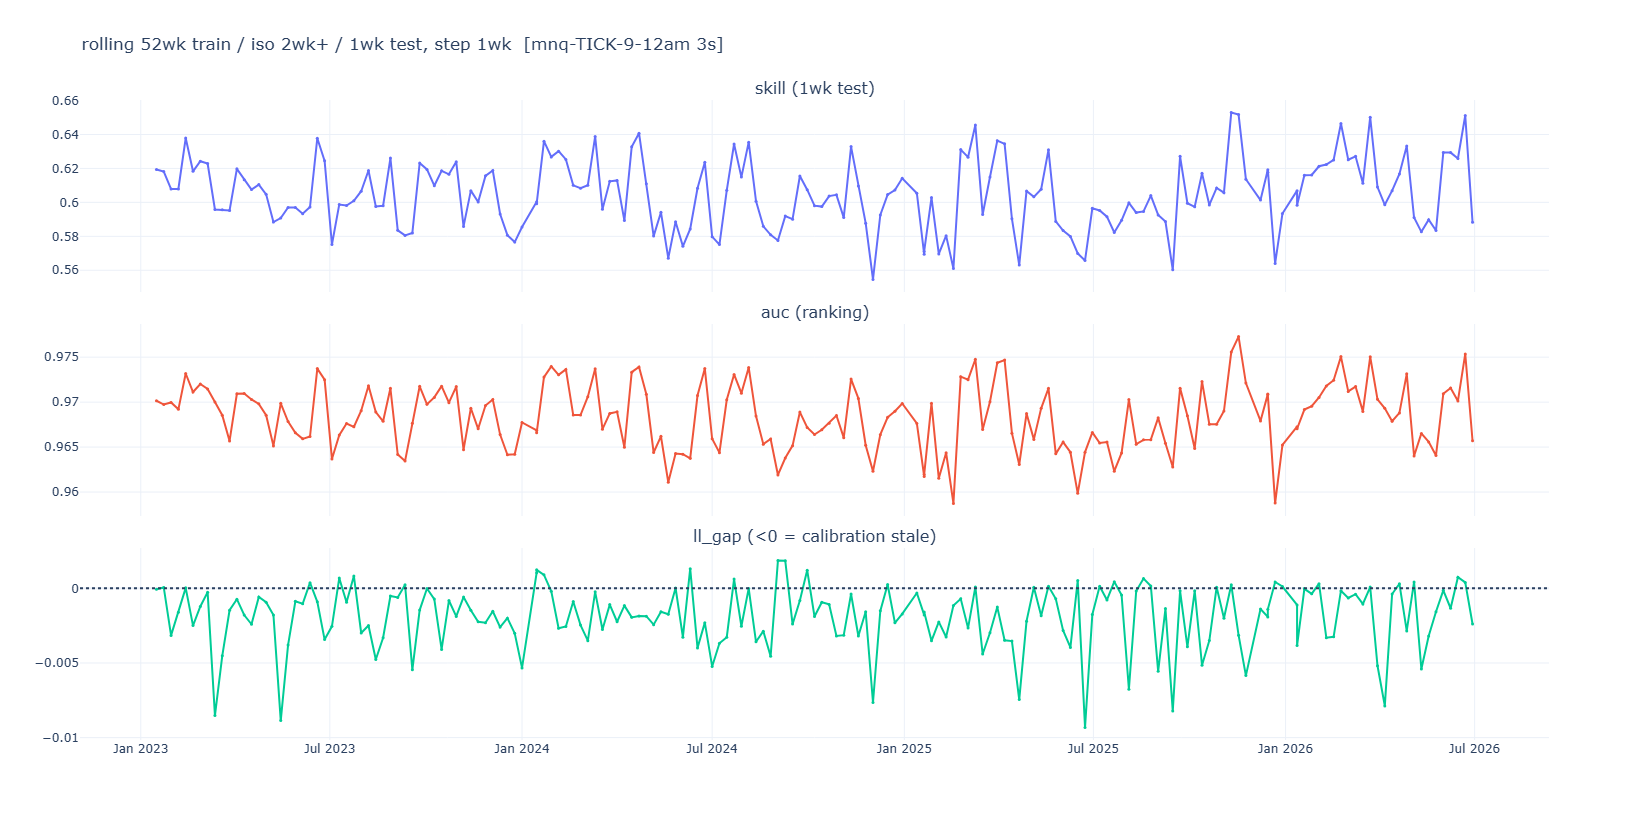

In [5]:
df = run()

In [ ]:
'''
TODO: FIND OUT IF THEY ARE REAL (Claude says its noise)

NOTE LARGE INCURSIONS in LL_GAP
===============================
2023-03-13
2023-05-15
2024-12-02
2025-04-21
2025-08-04
2025-09-15
2026-04-06

'''